# Лабораторная работа №9

## Баканов Сергей ИБМ3-65Б

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

plt.style.use('seaborn-v0_8')

In [7]:
df = pd.read_csv("customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [8]:
encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(
    df['Gender']
)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [10]:
features = [

    'Gender',
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'

]

D1 = df[features]

In [11]:
scaler = StandardScaler()

D1_scaled = scaler.fit_transform(
    D1
)

D1_scaled.shape

(200, 4)

In [12]:
pca = PCA(
    n_components=2,
    random_state=42
)

D2 = pca.fit_transform(
    D1_scaled
)

print(
    pca.explained_variance_ratio_
)

[0.33690046 0.26230645]


In [13]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

D3 = tsne.fit_transform(
    D1_scaled
)

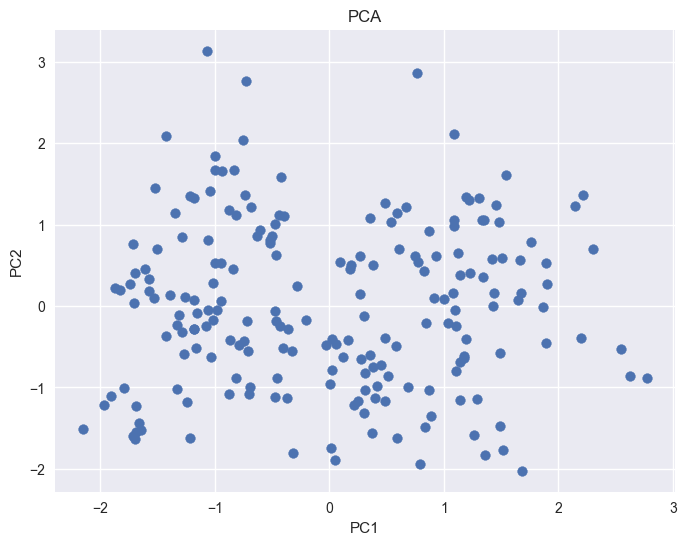

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    D2[:,0],
    D2[:,1]
)

plt.title('PCA')

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

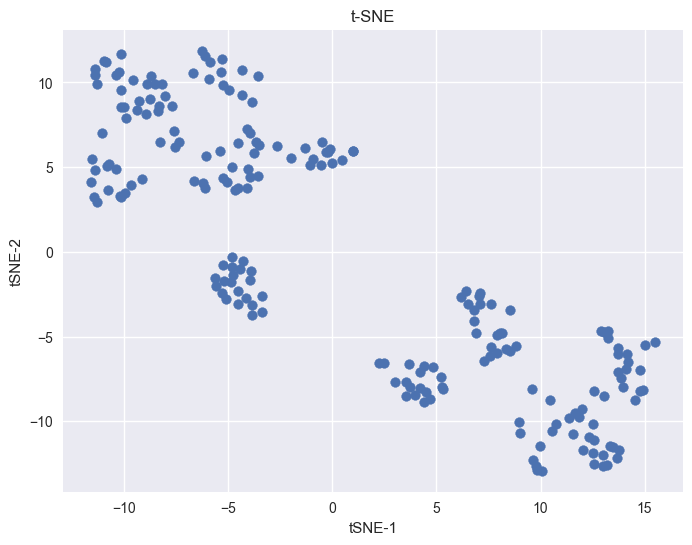

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    D3[:,0],
    D3[:,1]
)

plt.title('t-SNE')

plt.xlabel('tSNE-1')
plt.ylabel('tSNE-2')

plt.show()

In [16]:
datasets = {

    'D1': D1_scaled,
    'D2': D2,
    'D3': D3

}

In [17]:
def evaluate_clustering(
    X,
    labels
):

    if len(np.unique(labels)) < 2:

        return None

    return {

        'Silhouette':

        silhouette_score(
            X,
            labels
        ),

        'Calinski-Harabasz':

        calinski_harabasz_score(
            X,
            labels
        ),

        'Davies-Bouldin':

        davies_bouldin_score(
            X,
            labels
        )
    }

In [18]:
results = []

for dataset_name, X in datasets.items():

    models = {

        'KMeans':

        KMeans(
            n_clusters=5,
            random_state=42
        ),

        'Agglomerative':

        AgglomerativeClustering(
            n_clusters=5
        ),

        'DBSCAN':

        DBSCAN(
            eps=0.8,
            min_samples=5
        )
    }

    for model_name, model in models.items():

        labels = model.fit_predict(X)

        metrics = evaluate_clustering(
            X,
            labels
        )

        if metrics:

            results.append({

                'Dataset': dataset_name,

                'Method': model_name,

                'Silhouette':
                metrics['Silhouette'],

                'Calinski-Harabasz':
                metrics['Calinski-Harabasz'],

                'Davies-Bouldin':
                metrics['Davies-Bouldin']
            })

results_df = pd.DataFrame(
    results
)

results_df

C:\Users\nobro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nobro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nobro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Dataset,Method,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,D1,KMeans,0.271910,62.126342,1.181091
1,D1,Agglomerative,0.286994,64.468707,1.219773
2,D1,DBSCAN,0.172099,28.747862,2.736189
3,D2,KMeans,0.403769,169.212535,0.846995
4,D2,Agglomerative,0.345819,150.200279,0.911109
5,D2,DBSCAN,0.384495,7.823805,0.771251
6,D3,KMeans,0.524021,718.320096,0.735484
7,D3,Agglomerative,0.522990,702.730887,0.726749
8,D3,DBSCAN,0.020947,17.963537,1.229158


In [19]:
results_df.sort_values(
    by='Silhouette',
    ascending=False
)

,Dataset,Method,Silhouette,Calinski-Harabasz,Davies-Bouldin
6,D3,KMeans,0.524021,718.320096,0.735484
7,D3,Agglomerative,0.522990,702.730887,0.726749
3,D2,KMeans,0.403769,169.212535,0.846995
5,D2,DBSCAN,0.384495,7.823805,0.771251
4,D2,Agglomerative,0.345819,150.200279,0.911109
1,D1,Agglomerative,0.286994,64.468707,1.219773
0,D1,KMeans,0.271910,62.126342,1.181091
2,D1,DBSCAN,0.172099,28.747862,2.736189
8,D3,DBSCAN,0.020947,17.963537,1.229158


C:\Users\nobro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


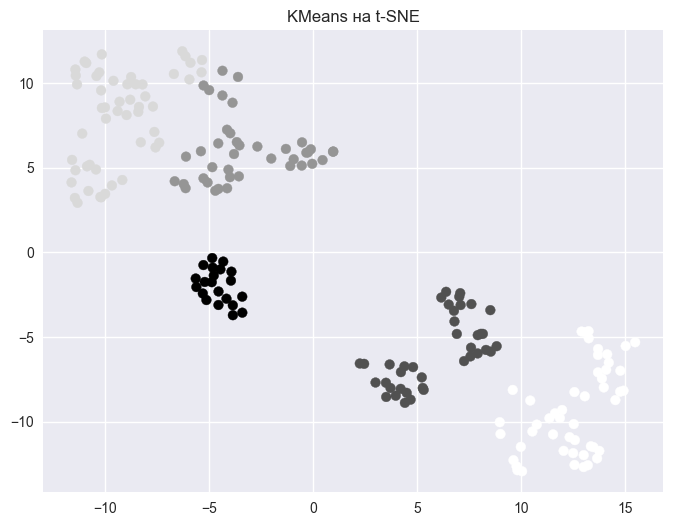

In [20]:
best_model = KMeans(
    n_clusters=5,
    random_state=42
)

labels = best_model.fit_predict(
    D3
)

plt.figure(figsize=(8,6))

plt.scatter(

    D3[:,0],
    D3[:,1],

    c=labels

)

plt.title(
    'KMeans на t-SNE'
)

plt.show()